# T13 — The other sign: mountains, and why extension is the harder direction

**Cluster D — Part 3, lithospheric deformation.** Requires the container.

T09 opened Part 3 with an observation: G-ADOPT's Drucker–Prager benchmark is a
lithospheric *shortening* model, and extension is the same model with one sign
flipped. That was an instantaneous solve — nothing moved, nothing accumulated.

Four notebooks later the model has advected materials, accumulated plastic
strain, strain weakening, an evolving geotherm and a free surface. This notebook
flips the sign again, with all of that engaged, and the two experiments now
differ in ways the instantaneous version could not show:

* one builds a **basin**, the other a **mountain**;
* one confines deformation to the crust, the other reaches the mantle lithosphere;
* and one of them can be pushed nearly twice as far before the model stops being
  able to represent itself.

## Learning objectives

1. Predict, from mass conservation alone, which way a free surface moves under each sign.
2. Read a doubly-vergent crustal structure and say what sets its depth extent.
3. Explain why a numerical ceiling can be asymmetric in a symmetric-looking pair of experiments.
4. Distinguish a bivergent orogen from a critical-taper wedge, and know what the latter would require.

## Prerequisites and runtime

* T09 through T12. **Requires the container.**
* **Measured runtime: about 10 minutes.** Two runs, one of which is expected to
  stop early.

In [1]:
# === USER CONFIGURATION ===
NX, NY = 48, 24
STEPS = 40
DT_MAX = 4e-3          # 16% strain if all steps complete; see section 4
CRUST_KM = 35.0

In [2]:
import json
import os
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
from geodynkit import plotting

DRIVER = os.path.join("..", "tools", "gadopt_rift_case.py")


def run(mode):
    cmd = [sys.executable, DRIVER, "--nx", str(NX), "--ny", str(NY),
           "--steps", str(STEPS), "--thermal", "--free-surface",
           "--mode", mode, "--crust-km", str(CRUST_KM), "--seed-km", "10",
           "--dt-max", str(DT_MAX), "--out", f"t13_{mode}.npz"]
    p = subprocess.run(cmd, capture_output=True, text=True)
    for line in p.stdout.splitlines():
        if line.startswith("RESULT "):
            return json.loads(line[len("RESULT "):])
    raise RuntimeError(f"no result:\n{p.stderr[-1500:]}")

## 1. The sign, and what it commits you to

```python
sgn = -1.0 if mode == "extension" else 1.0
bcs = {left: {"ux": sgn * 1}, right: {"ux": -sgn * 1}, bottom: {"uy": 0}}
```

Everything else is identical: same rheology, same layer structure, same
geotherm, same seed, same solver settings.

Before running, the free surface can be predicted from mass conservation alone.
The mesh is fixed and the base is no-flux, so whatever crosses the side walls
must cross the top. Drive the walls **apart** and material leaves through the
sides, so the surface must come down — T11's rift basin. Drive them **together**
and material is pushed in, so it has nowhere to go but up.

That is not a subtle prediction, but it is a real one, and it is worth making
before looking.

In [3]:
res = {m: run(m) for m in ("shortening", "extension")}
print(f"{'':>12} {'steps':>12} {'strain %':>9} {'W50':>7} {'peak':>6} {'topography (km)':>22}")
for m, r in res.items():
    done = f"{r['steps_completed']}/{r['steps_requested']}"
    pct = 100 * r["steps_completed"] * r["dt_max"]
    lo, hi = r["topography_km"]
    print(f"{m:>12} {done:>12} {pct:>9.1f} {r['w50']:>7} {r['strain_max_final']:>6.2f} "
          f"{lo:>+10.1f} to {hi:>+7.1f}")

                    steps  strain %     W50   peak        topography (km)
  shortening        40/40      16.0  0.1244   2.62       +9.8 to   +27.5
   extension        23/40       9.2  0.1503   2.27      -14.1 to    -7.0


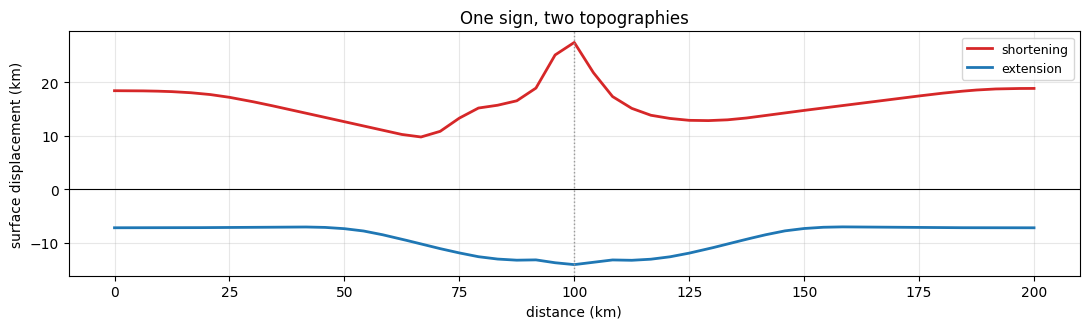

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.4))
for m, c in (("shortening", "C3"), ("extension", "C0")):
    d = np.load(f"t13_{m}.npz")
    ax.plot(d["x_km"], d["topography_km"], c, lw=2, label=m)
ax.axhline(0, color="k", lw=0.8)
ax.axvline(100, color="0.6", ls=":", lw=1)
ax.set(xlabel="distance (km)", ylabel="surface displacement (km)",
       title="One sign, two topographies")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

A mountain and a basin, from the same model.

**Read the relief, not the absolute height** — the same caveat as T11, and for
the same reason. $\eta$ is the time-integral of the normal velocity at the top,
and the box must take in through its walls whatever the boundary condition
dictates, so the *mean* displacement is bookkeeping for material transport. The
axis-to-far-field difference is the part the physics sets.

Even that is too large: about 18 km of relief where a real orogen manages five.
The missing ingredient is **erosion**. A real wedge grows until removal at the
surface balances accretion at depth; this one has no removal term at all, so it
simply keeps growing.

## 2. Where the deformation goes

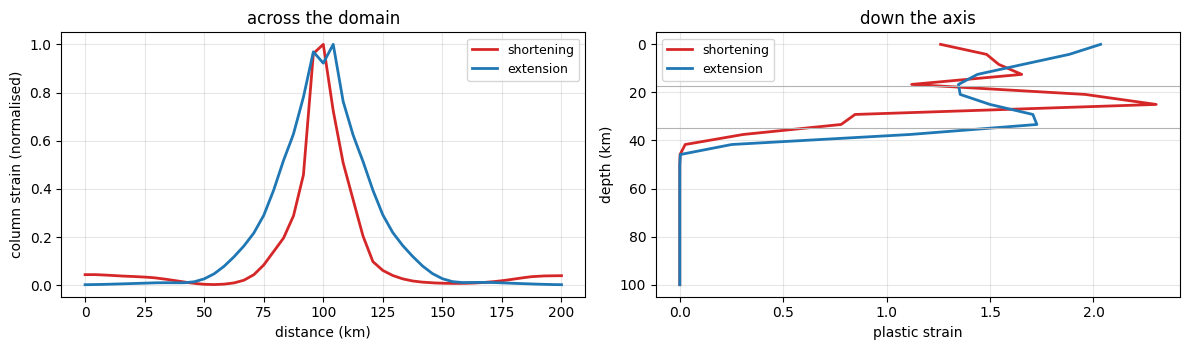

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for k, (m, c) in enumerate((("shortening", "C3"), ("extension", "C0"))):
    d = np.load(f"t13_{m}.npz")
    col = np.maximum(d["strain"], 0).sum(axis=0)
    ax[0].plot(d["x_km"], col / col.max(), c, lw=2, label=m)
    j = int(np.argmin(np.abs(d["x_km"] - 100)))
    ax[1].plot(d["strain"][:, j], d["depth_km"], c, lw=2, label=m)
ax[0].set(xlabel="distance (km)", ylabel="column strain (normalised)",
          title="across the domain")
ax[1].set(xlabel="plastic strain", ylabel="depth (km)", title="down the axis")
ax[1].invert_yaxis()
for a in ax:
    a.legend(fontsize=9)
    a.grid(alpha=0.3)
for b in (CRUST_KM / 2, CRUST_KM):
    ax[1].axhline(b, color="0.7", lw=0.8)
fig.tight_layout()
plt.show()

In [6]:
for m in ("shortening", "extension"):
    d = np.load(f"t13_{m}.npz")
    z, j = d["depth_km"], int(np.argmin(np.abs(d["x_km"] - 100)))
    prof = d["strain"][:, j]
    deep = z[np.max(np.nonzero(prof > 0.5)[0])] if (prof > 0.5).any() else float("nan")
    col = np.maximum(d["strain"], 0).sum(axis=0)
    print(f"{m:>12}: deformation reaches {deep:5.1f} km depth; "
          f"column strain at the walls {col[0] / col.max():.3f} / {col[-1] / col.max():.3f}")

  shortening: deformation reaches  35.4 km depth; column strain at the walls 0.044 / 0.039
   extension: deformation reaches  39.6 km depth; column strain at the walls 0.002 / 0.002


Both localise on the seed, and both fall to a few percent at the walls — neither
is diffuse.

The difference is in depth, and it is real but modest: shortening stops
essentially at the Moho (35.4 km, against a 35 km crust) while extension carries
deformation about five kilometres into the mantle lithosphere. Do not oversell
that gap — it is one or two cells at this resolution — but the sign of it is
what the layer geometry predicts. Shortening **thickens** the crust, pushing the
strong mantle lithosphere further from the deforming zone; extension **thins**
it, drawing the mantle lithosphere up towards it.

The structure at the axis is a **doubly-vergent pop-up**: conjugate thrusts
rooted at depth and converging upward, the crustal-scale version of what
a bivergent orogen produces when convergence is symmetric and there is no
preferred subduction polarity.

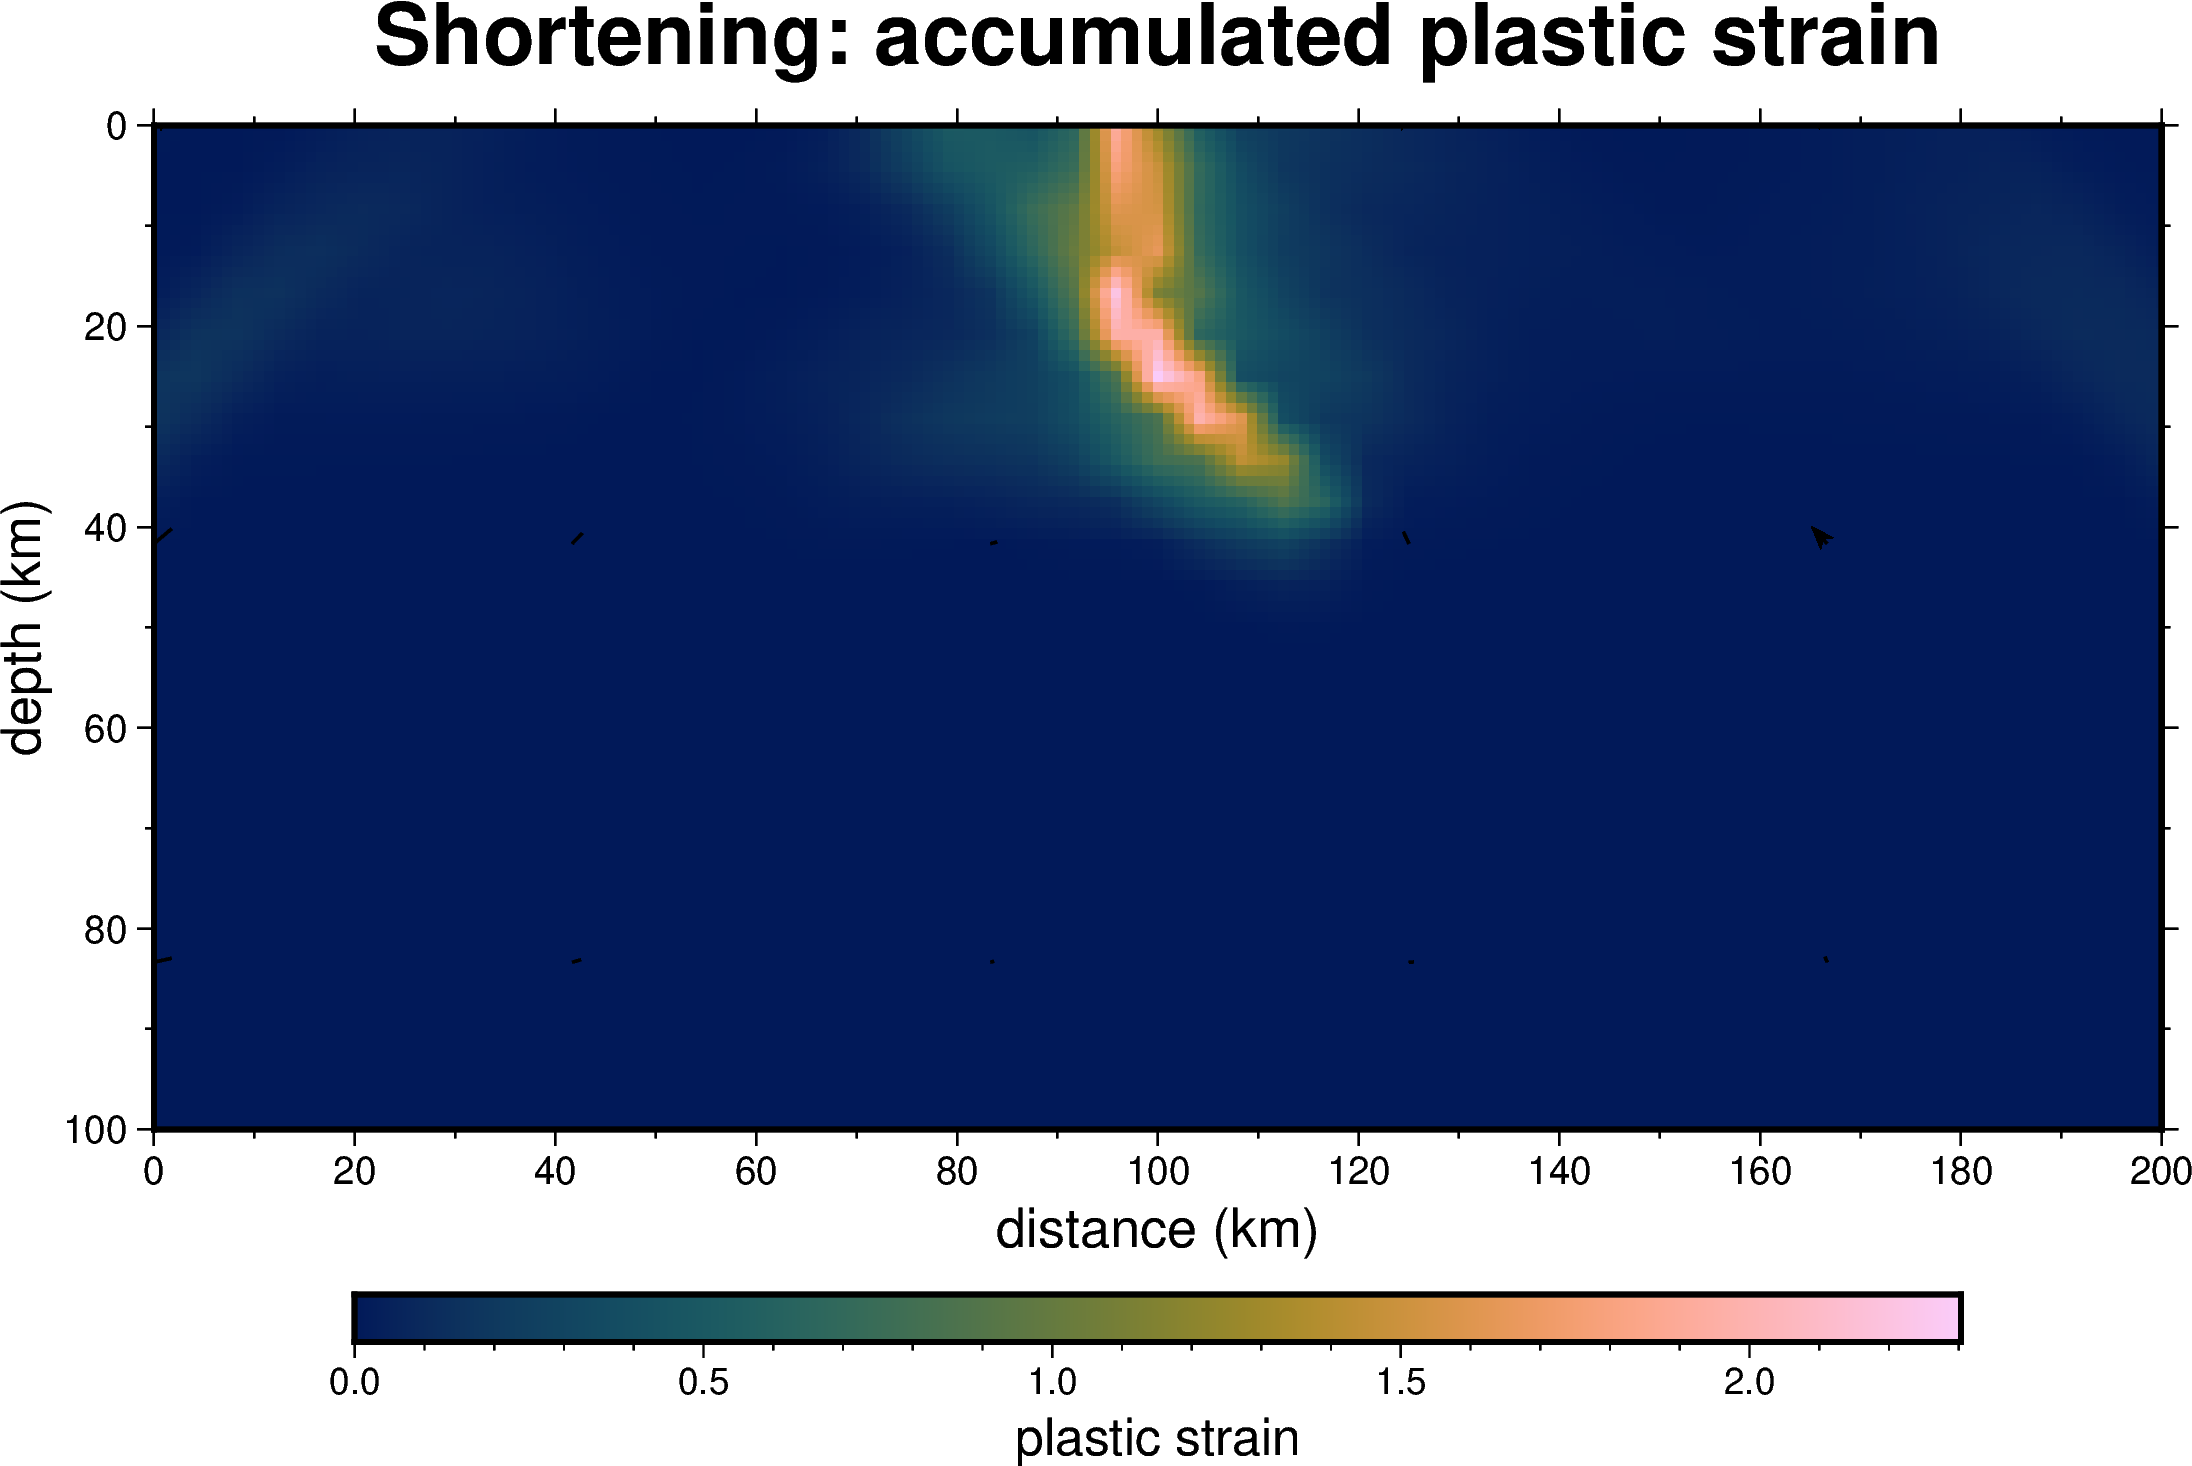

In [7]:
d = np.load("t13_shortening.npz")
fig = plotting.field_panel(
    d["strain"], d["x_km"], d["depth_km"], kind="strain_rate",
    title="Shortening: accumulated plastic strain",
    label="plastic strain", vx=d["vx"], vz=d["vz"], every=40, width_cm=17.0,
)
fig.show()

## 3. Extension is the harder direction, and now it is quantitative

T09 measured this as an iteration count: 34 Picard iterations for extension
against 18 for shortening, at identical resolution and tolerance, because in
shortening rising pressure raises the yield stress and pushes material back
towards the ductile branch, while in extension the feedback runs the other way.

With the full machinery the same asymmetry shows up as something harder than a
cost — **a limit on how far the experiment can go at all.** Look at the steps
column in section 1: shortening completes all forty, extension stops at
twenty-three.

In [8]:
for m, r in res.items():
    print(f"{m:>12}: {r['steps_completed']:>2}/{r['steps_requested']} steps, "
          f"{100 * r['steps_completed'] * r['dt_max']:>4.1f}% strain, "
          f"psi excursion {r['level_set_excursion']:.4f}")
    if r["failure"]:
        print(f"{'':>14}{r['failure'][:96]}")

  shortening: 40/40 steps, 16.0% strain, psi excursion 0.0048
   extension: 23/40 steps,  9.2% strain, psi excursion 0.0932
              AdvectionBroke: level set range [-0.0032, 1.0932] at step 22: the conservative level set must st


Extension trips the conservative-level-set invariant from T10; shortening never
comes close.

The reason is geometric, and once seen it is obvious. T10 established that the
level-set description fails when a layer thins to about three or four cells.
**Extension thins layers — it walks towards that limit. Shortening thickens
them — it walks away from it.** The two experiments differ by a sign, and that
sign decides whether the numerics get harder or easier as the model runs.

This is worth carrying beyond rifting. When a method has a resolution floor tied
to a feature size, the *direction* of the deformation determines whether time
improves your situation or degrades it, and a symmetric-looking pair of
experiments can have wildly asymmetric cost.

## 4. What this is not: a critical-taper wedge

The obvious next thing to ask of a shortening model is **critical taper** — the
Davis, Suppe & Dahlen result that a Coulomb wedge self-organises to a surface
slope set by the ratio of basal to internal friction, and that the whole wedge
fails when it is subcritical.

This model does not produce one, and the reason is the setup rather than the
physics. A taper needs three things it does not have:

1. a **basal décollement** — a weak layer the wedge slides along, rather than a
   free-slip boundary with the same friction as everything else;
2. a **backstop** — a rigid buttress at one end;
3. a **one-sided feed** — material delivered from one side onto a stationary
   plate, rather than symmetric convergence from both.

Symmetric convergence with a seed at the centre gives a bivergent pop-up, which
is a real structure and a different one. The measured surface profile confirms
it: a narrow high at the axis inside a broad depression, with the far field
elevated by the material being fed in — not a wedge tapering away from a
backstop.

Building the taper case is a change of geometry rather than of physics, and all
three ingredients are expressible in what this driver already does: a
low-friction layer through `material_field`, a velocity boundary condition on
part of the base for the conveyor, and a strong-viscosity region for the
backstop. It is a good next project and is deliberately not attempted here.

## 5. Where Part 3 ends up

| | T09 | T10 | T11 | T12 | T13 |
|---|---|---|---|---|---|
| visco-plastic rheology | yes | yes | yes | yes | yes |
| time-dependent, strain weakening | — | yes | yes | yes | yes |
| evolving topography | — | — | yes | yes | yes |
| evolving temperature | — | — | — | yes | yes |
| both signs, fully coupled | — | — | — | — | **yes** |

The suite now runs a lithospheric deformation model with advected layered
materials, accumulated plastic strain, strain weakening, a solved geotherm and a
deformable surface, in extension and in shortening, with invariants that stop it
when the material description stops meaning anything.

What it does not do is reach the large finite strains at which the interesting
classification problems live — rifting modes (T12), critical taper (this
notebook). Both are blocked by the same thing: the level-set representational
ceiling at 15–25% strain on a 2 km mesh. That is the honest edge of this suite,
and it is a resolution problem rather than a physics one.

## Extend this

* Add an erosion term — remove material above a threshold elevation each step — and see whether the relief settles instead of growing without bound.
* Build the critical-taper setup from section 4 and measure the surface slope against the Davis–Suppe–Dahlen prediction. Start with a basal friction angle well below the internal one.
* Push shortening past 16%. How far does it get before *its* invariant fires, and does the failure look like extension's?
* Compare the depth extent of deformation as a function of crustal thickness in shortening. Does a thick, hot crust decouple in shortening the way T12 expected it to in extension?
* Run shortening with distributed noise instead of a centred seed (T12's `--seed-mode random`). Does it select a single pop-up, or several?